# Processing RF slicing data

In [1]:
import glob
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import os
from matplotlib import ticker
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as pipelinelib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

temp_groups = ['205', '218', '225']
color_map = {
    '205': 'gray',
    '218': 'red',
    '225': 'green'
}

rho_ice = 917.0  # kg/m^3, used for CoCiP mass calculation
model_colors = {"APCEMM": "tab:blue", "LES": "tab:orange", "CoCiP": "tab:green"}
rh_styles = {110: "--", 130: "-"}

test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours = [0, 12]
habits = ['ghm', 'solid-column', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

# APCEMM
apcemm_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

apcemm_default_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/default_settings/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
cocip_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# LES
les_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/LES/{tid}/LES_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

In [2]:
test_id = '110T205L25'
habit = 'ghm'
hour = 12
EVOL_PLOT_DS = apcemm_data[(test_id, hour, habit)]

In [3]:
EVOL_PLOT_DS

<xarray.Dataset>
Dimensions:                      (t: 211, r_b: 1001, y: 717, x: 3381, r: 1000,
                                  slice: 25)
Coordinates:
  * x                            (x) float32 -1.648e+04 -1.643e+04 ... 1.397e+05
  * y                            (y) float32 -1.495e+03 -1.485e+03 ... 347.8
  * r                            (r) float32 5.541e-08 5.581e-08 ... 7.797e-05
  * t                            (t) float64 0.0 0.1675 0.3349 ... 35.0 35.17
  * slice                        (slice) int64 0 1 2 3 4 5 ... 19 20 21 22 23 24
Dimensions without coordinates: r_b
Data variables: (12/32)
    r_e                          (t, r_b) float32 ...
    Pressure                     (t, y) float32 ...
    Altitude                     (t, y) float32 ...
    H2O                          (t, y, x) float32 ...
    Temperature                  (t, y, x) float32 ...
    Ice aerosol particle number  (t, y, x) float32 ...
    ...                           ...
    LW RF midnight               (t) float64 ...
    SW RF noon                   (t) float64 ...
    LW RF noon                   (t) float64 ...
    Energy Forcing               (t) float64 ...
    Habit                        <U3 ...
    Hour                         <U2 ...
Attributes:
    FileName:         /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_...
    Author:           Thibaud M. Fritz (fritzt@mit.edu)
    Contact:          Thibaud M. Fritz (fritzt@mit.edu)
    Generation Date:  05-05-2026 14:51:47
    Format:           NetCDF-4

In [10]:
test_id = '110T218L25'
habit = 'ghm'
hour = 12

apcemm_output = pipelinelib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/{test_id}/outputs',
    )
EVOL_PLOT_DS = apcemm_data[(test_id, hour, habit)]

ds_data_all = apcemm_output.ds_t

fig, ax = plt.subplots(figsize=(6, 4), dpi=1000)
ax.set_ylabel("y [km]", fontsize=14)
ax.set_ylim(9, 11)
ax.set_xlim(-20, 150)
ax.set_xlabel("x [km]", fontsize=14)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))   # tick every 0.2 km
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # 1 decimal place

# --- initialise mesh and colorbar once, before the animation ---
vmin, vmax = 0.1, 10

ds_data_init = ds_data_all[1]
x_vals_init  = ds_data_init["x"].values
y_vals_init  = ds_data_init["y"].values

cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)
cmap.set_under(color='white', alpha=0)

# create a dummy mappable just for the colorbar — no mesh drawn on the axes
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, label="IWC")
cbar.formatter = ticker.ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()

plt.tight_layout()

fps_contrail = 4
num_timesteps = len(ds_data_all) -1

# outside the function — initialise with a reference to the axes image list
im_container = [None]  # mutable container so the closure can update it

def update_contrail_frame(frame_idx):
    frame_idx = frame_idx +1
    time = frame_idx * 10 / 60

    ds_data   = ds_data_all[frame_idx]
    x_vals    = ds_data["x"].values
    y_vals    = ds_data["y"].values
    reff_plot = ds_data["Effective radius"].values * 1e6
    iwc_plot = ds_data["IWC"].values

    valid_mask  = np.isfinite(reff_plot) & (reff_plot > 0)
    masked_iwc = np.where(valid_mask, iwc_plot, np.nan)

    ax.set_title(f"APCEMM:  Age {time*60:.0f} minutes", fontsize=14)
    ax.axhline(10.2, color='red')

    # remove the previous mesh (not the colorbar)
    if im_container[0] is not None:
        im_container[0].remove()

    im_container[0] = ax.pcolormesh(
        x_vals/1000, y_vals / 1000 + 10.7, masked_iwc,
        cmap=cmap
    )

    # keep colorbar pointed at the current mesh
    cbar.update_normal(im_container[0])

    return (im_container[0],)

anim_contrail = FuncAnimation(
    fig, update_contrail_frame, frames=num_timesteps,
    interval= 1000 / fps_contrail, blit=False
)

output_path_contrail = (
    f"/home/chinahg/GCresearch/contrailuncertainty/"
    f"APCEMM_vs_CoCiP_vs_LES/Figures/a_RF_{hour}h_{habit}_{test_id}_IWC.mp4"
)
writer_contrail = FFMpegWriter(fps=fps_contrail, bitrate=2000)
anim_contrail.save(output_path_contrail, writer=writer_contrail)

print(f"Contrail evolution video saved to: {output_path_contrail}")
plt.close()

Contrail evolution video saved to: /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/Figures/a_RF_12h_ghm_110T218L25_IWC.mp4


In [6]:
test_id = '110T205L25'
habit = 'ghm'
hour = 12

apcemm_output = pipelinelib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/{test_id}/outputs',
    )
EVOL_PLOT_DS = apcemm_data[(test_id, hour, habit)]

ds_data_all = apcemm_output.ds_t

fig, ax = plt.subplots(figsize=(6, 4), dpi=1000)
ax.set_ylabel("y [km]", fontsize=14)
ax.set_ylim(9, 11)
ax.set_xlim(-20, 150)
ax.set_xlabel("x [km]", fontsize=14)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))   # tick every 0.2 km
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # 1 decimal place

# --- initialise mesh and colorbar once, before the animation ---
vmin, vmax = 0, 30  # micron

ds_data_init = ds_data_all[1]
x_vals_init  = ds_data_init["x"].values
y_vals_init  = ds_data_init["y"].values

cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)
cmap.set_under(color='white', alpha=0)

# create a dummy mappable just for the colorbar — no mesh drawn on the axes
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, label="Effective Radius [micron]")
cbar.formatter = ticker.ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()

plt.tight_layout()

fps_contrail = 4
num_timesteps = len(ds_data_all) -1

# outside the function — initialise with a reference to the axes image list
im_container = [None]  # mutable container so the closure can update it

def update_contrail_frame(frame_idx):
    frame_idx = frame_idx +1
    time = frame_idx * 10 / 60

    ds_data   = ds_data_all[frame_idx]
    x_vals    = ds_data["x"].values
    y_vals    = ds_data["y"].values
    reff_plot = ds_data["Effective radius"].values * 1e6

    valid_mask  = np.isfinite(reff_plot) & (reff_plot > 0)
    masked_reff = np.where(valid_mask, reff_plot, np.nan)

    ax.set_title(f"APCEMM:  Age {time*60:.0f} minutes", fontsize=14)
    ax.axhline(10.2, color='red')

    # remove the previous mesh (not the colorbar)
    if im_container[0] is not None:
        im_container[0].remove()

    im_container[0] = ax.pcolormesh(
        x_vals/1000, y_vals / 1000 + 10.7, masked_reff,
        cmap=cmap, vmin=vmin, vmax=vmax
    )

    # keep colorbar pointed at the current mesh
    cbar.update_normal(im_container[0])

    return (im_container[0],)

anim_contrail = FuncAnimation(
    fig, update_contrail_frame, frames=num_timesteps,
    interval= 1000 / fps_contrail, blit=False
)

output_path_contrail = (
    f"/home/chinahg/GCresearch/contrailuncertainty/"
    f"APCEMM_vs_CoCiP_vs_LES/Figures/a_RF_{hour}h_{habit}_{test_id}.mp4"
)
writer_contrail = FFMpegWriter(fps=fps_contrail, bitrate=2000)
anim_contrail.save(output_path_contrail, writer=writer_contrail)

print(f"Contrail evolution video saved to: {output_path_contrail}")
plt.close()

Contrail evolution video saved to: /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/Figures/a_RF_12h_ghm_110T205L25.mp4


In [9]:
# ── Configuration ────────────────────────────────────────────────────────────
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse

# ── Helpers ───────────────────────────────────────────────────────────────────

def cocip_ellipse_plot(width, depth, shear_strain, center=(0, 0), ax=None, **ellipse_kwargs):
    sigma_yy = 0.125 * width ** 2
    sigma_zz = 0.125 * depth ** 2
    sigma_yz = shear_strain * sigma_zz

    cov = np.array([[sigma_yy, sigma_yz],
                    [sigma_yz, sigma_zz]])

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    eigvals = np.maximum(eigvals, 0)

    axis_lengths = 2 * np.sqrt(eigvals)
    angle_deg = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    t = np.linspace(0, 2 * np.pi, 500)
    circle = np.array([np.cos(t), np.sin(t)])
    sheared = eigvecs @ np.diag(np.sqrt(eigvals)) @ circle

    x_ell = sheared[0] + center[0]
    y_ell = sheared[1] + center[1]

    if ax is not None:
        ellipse = Ellipse(
            xy=center,
            width=axis_lengths[0],
            height=axis_lengths[1],
            angle=angle_deg,
            facecolor="none",
            edgecolor=ellipse_kwargs.pop("edgecolor", "C3"),
            **ellipse_kwargs
        )
        ax.add_patch(ellipse)
        ax.plot(center[0], center[1], "kx", ms=8)

    return angle_deg, tuple(axis_lengths), x_ell, y_ell


def build_cocip_ellipse(time_idx, KEY_C):
    width = ds_cocip["width"].values[time_idx] /1000
    area = ds_cocip["area_eff"].values[time_idx] /(1000*1000)
    depth = ds_cocip["depth"].values[time_idx] /1000
    sigma_yz = ds_cocip["sigma_yz"].values[time_idx] /(1000*1000)
    bulk_property = ds_cocip[KEY_C].values[time_idx] * 1e6

    shear_strain = sigma_yz / (0.125 * depth ** 2)

    angle_deg, axis_lengths, x_ell, y_ell = cocip_ellipse_plot(
        width, depth, shear_strain, center=(0, 0), ax=None
    )


    current_area = np.pi * (axis_lengths[0] * axis_lengths[1]) / 4
    scale = np.sqrt(area / current_area)

    x_ell = x_ell * scale
    y_ell = y_ell * scale

    x_pad = (x_ell.max() - x_ell.min()) * X_BUFFER
    x_grid = np.linspace(x_ell.min() - x_pad, x_ell.max() + x_pad, GRID_RES)

    return dict(
        x_ell=x_ell,
        y_ell=y_ell,
        x_grid=x_grid,
        y_extent=np.abs(y_ell).max(),
        bulk_value=bulk_property,
        angle_deg=angle_deg,
        a_sol=None,
        b_sol=None,
        altitude=ds_cocip["altitude"].values[time_idx],
    )

# ── Configuration ─────────────────────────────────────────────────────────────
vmin, vmax   = 1, 30
fps_cocip    = 4
COLORMAP     = "viridis"
FONTSIZE     = 14
PROPERTY     = "r_ice_vol"
GRID_RES   = 220
X_BUFFER   = 0.10

ds_cocip = cocip_data[(test_id, hour, habit)]

cmap = plt.cm.get_cmap(COLORMAP).copy()
cmap.set_bad(alpha=0)
cmap.set_under(color='white', alpha=0)
shared_norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ── Pre-compute all CoCiP ellipses ────────────────────────────────────────────
ds_cocip_timesteps = len(ds_cocip["age_hours"])   # or however time is indexed
all_ellipses = {idx: build_cocip_ellipse(idx, PROPERTY) for idx in range(ds_cocip_timesteps)}

# ── Compute shared x/y limits across all frames ───────────────────────────────
all_x = np.concatenate([cd["x_ell"] for cd in all_ellipses.values()])
all_y = np.concatenate([cd["y_ell"] for cd in all_ellipses.values()])
x_range = all_x.max() - all_x.min()
y_lo    = all_y.min()
y_hi    = all_y.max()
pad     = (y_hi - y_lo) * 0.1

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), dpi=1000)
ax.set_xlabel("x [km]",  fontsize=FONTSIZE)
ax.set_ylabel("y [km]",  fontsize=FONTSIZE)
ax.set_xlim(-20, 150)
ax.set_ylim(9, 11)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))   # tick every 0.2 km
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))  # 1 decimal place

# ── Static colorbar (dummy mappable, created once) ────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=shared_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Effective Radius [μm]")
cbar.ax.tick_params(labelsize=FONTSIZE)

plt.tight_layout()

# ── Mutable containers so closures can update artists ─────────────────────────
fill_container = [None]
line_container = [None]
mark_container = [None]

def update_cocip_frame(frame_idx):
    cd   = all_ellipses[frame_idx]
    time_min = frame_idx * 10 +10          # adjust if your timestep spacing differs

    x_ell_c = cd["x_ell"] + 60
    y_ell   = cd["y_ell"] + cd['altitude']/1000 - cd['y_extent']/(2*1000)
    color   = cmap(shared_norm(cd["bulk_value"]))

    ax.set_title(f"CoCiP:  Age {time_min} min",
                 fontsize=FONTSIZE)

    # remove previous artists
    for container in (fill_container, line_container, mark_container):
        if container[0] is not None:
            container[0].remove()
            container[0] = None

    fill_container[0], = ax.fill(x_ell_c, y_ell,
                                  color=color, zorder=2)
    line_container[0], = ax.plot(x_ell_c, y_ell,
                                  color="none", lw=0.8, zorder=3)
    ax.axhline(10.2, color='red')
    mark_container[0], = ax.plot(x_ell_c.mean(), y_ell.mean(),
                              marker="o", ms=4, mew=1.5,
                              color="red", zorder=5)

    return fill_container[0], line_container[0], mark_container[0]

# ── Animate ───────────────────────────────────────────────────────────────────
anim_cocip = FuncAnimation(
    fig, update_cocip_frame, frames=ds_cocip_timesteps,
    interval=1000 / fps_cocip, blit=False
)

output_path_cocip = (
    f"/home/chinahg/GCresearch/contrailuncertainty/"
    f"APCEMM_vs_CoCiP_vs_LES/Figures/c_RF_{hour}h_{habit}_{test_id}.mp4"
)
writer_cocip = FFMpegWriter(fps=fps_cocip, bitrate=2000)
anim_cocip.save(output_path_cocip, writer=writer_cocip)

print(f"CoCiP evolution video saved to: {output_path_cocip}")
plt.close()

CoCiP evolution video saved to: /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/Figures/c_RF_12h_ghm_110T205L25.mp4


# Old

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.animation import FuncAnimation, FFMpegWriter
import warnings
import os
import glob
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib import ticker

import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as pipelinelib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

# APCEMM

In [ ]:
# Import APCEMM dataset
test_id = "110T218L25"
APCEMM_data = pipelinelib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/{test_id}/outputs'
)

APCEMM_ds = APCEMM_data.ds_t

## Get LRT input values from APCEMM input

In [9]:
timesteps_hours = np.arange(len(APCEMM_ds)) * 10 / 60  # Convert each timestep to hours
timesteps = np.arange(len(APCEMM_ds))
num_timesteps = len(timesteps)
total_num_slices_averaged = 25

APCEMM_depth = []
APCEMM_IWC_avg = []
APCEMM_radii = []

APCEMM_IWC_slice_avg = np.empty(num_timesteps, dtype=object)  # To store fixed-length slice averages for each timestep
APCEMM_radii_slice_avg = np.empty(num_timesteps, dtype=object)  # To store fixed-length slice averages for each timestep
APCEMM_depth_slice_avg = np.empty(num_timesteps, dtype=object)  # To store fixed-length slice averages for each timestep
APCEMM_ds_masked = np.empty(num_timesteps, dtype=object)  # To store masked datasets for each timestep

num_slices_array = np.zeros(num_timesteps, dtype=int)

for time_idx in timesteps:
    print(f"Processing time step {time_idx} / {num_timesteps-1} (t = {timesteps_hours[time_idx]:.2f} hours)")
    (iwc_slice_avg,
     radii_slice_avg,
     depth_slice_avg,
     iwc,
     radii,
     depth) = LRTlib.prepare_APCEMM_slices(
        APCEMM_ds, time_idx, total_num_slices_averaged
    )

    # fixed-length outputs
    APCEMM_IWC_slice_avg[time_idx] = iwc_slice_avg
    APCEMM_radii_slice_avg[time_idx] = radii_slice_avg
    APCEMM_depth_slice_avg[time_idx] = depth_slice_avg

    # variable-length outputs
    APCEMM_IWC_avg.append(iwc)
    APCEMM_radii.append(radii)
    APCEMM_depth.append(depth)

    num_slices_array[time_idx] = len(iwc)

    APCEMM_ds_masked[time_idx] = LRTlib.mask_IWC_95_percentile_IWC(APCEMM_ds, time_idx)


Processing time step 0 / 136 (t = 0.00 hours)
Number of slices at this timestep:  200
Number of valid slices after masking: 2
Processing time step 1 / 136 (t = 0.17 hours)
Number of slices at this timestep:  57
Number of valid slices after masking: 22
Processing time step 2 / 136 (t = 0.33 hours)
Number of slices at this timestep:  69
Number of valid slices after masking: 34
Number of slices exceeds 25, averaging every 1 slices to get 25 slices.
Processing time step 3 / 136 (t = 0.50 hours)
Number of slices at this timestep:  88
Number of valid slices after masking: 48
Number of slices exceeds 25, averaging every 1 slices to get 25 slices.
Processing time step 4 / 136 (t = 0.67 hours)
Number of slices at this timestep:  108
Number of valid slices after masking: 62
Number of slices exceeds 25, averaging every 2 slices to get 25 slices.


IndexError: index 31 is out of bounds for axis 0 with size 31

### Average the RF values across slices for each timestep and save to a CSV

In [ ]:
habits = ["rough-aggregate", "ghm", "solid-column"]
test_ids = ["110T218L25"]

for test_id in test_ids:
    APCEMM_data = pipelinelib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/outputs'
    )
    APCEMM_ds = APCEMM_data.ds_t
    rf_dir_base = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs"
    timesteps = np.arange(len(APCEMM_ds)-1)
    time_hours = timesteps * 10 / 60  # Convert each timestep to hours

    for habit in habits:
        rf_0h_slice_avg = []
        rf_12h_slice_avg = []
        rf_12h_slice_avg_sw_only = []
        rf_12h_slice_avg_lw_only = []
        
        for time_idx in timesteps:
            rf_dir_time = f"{rf_dir_base}/timestep_{time_idx}"
            csv_files_time = sorted(glob.glob(os.path.join(rf_dir_time, f"*{habit}*.csv")))

            df_list_time = [pd.read_csv(f) for f in csv_files_time]
    
            lw_0h_time = None
            lw_12h_time = None
            sw_12h_time = None
    
            for i, f in enumerate(csv_files_time):
                if "LW" in f and "0h" in f:
                    lw_0h_time = df_list_time[i]
                if "LW" in f and "12h" in f:
                    lw_12h_time = df_list_time[i]
                if "SW" in f and "12h" in f:
                    sw_12h_time = df_list_time[i]
            print(csv_files_time)
    
            # if the value is 0 dont include it in the average (will later be replaced with nan, but for now just skip it in the average)
            if lw_0h_time is not None:
                lw_0h_time["LW_Radiative_Forcing_W_m2"] = lw_0h_time["LW_Radiative_Forcing_W_m2"].replace(0, np.nan)
                rf_0h_slice_avg.append(lw_0h_time["LW_Radiative_Forcing_W_m2"].mean())
    
            if lw_12h_time is not None and sw_12h_time is not None:
                lw_12h_time["LW_Radiative_Forcing_W_m2"] = lw_12h_time["LW_Radiative_Forcing_W_m2"].replace(0, np.nan)
                sw_12h_time["SW_Radiative_Forcing_W_m2"] = sw_12h_time["SW_Radiative_Forcing_W_m2"].replace(0, np.nan)
                total_rf_12h = lw_12h_time["LW_Radiative_Forcing_W_m2"] + sw_12h_time["SW_Radiative_Forcing_W_m2"]
                rf_12h_slice_avg.append(total_rf_12h.mean())
                rf_12h_slice_avg_sw_only.append(sw_12h_time["SW_Radiative_Forcing_W_m2"].mean())
                rf_12h_slice_avg_lw_only.append(lw_12h_time["LW_Radiative_Forcing_W_m2"].mean())

        # Save the average RF values over time to three separate CSV files
        # Create dataframe for LW 0h
        rf_0h_df = pd.DataFrame({
            "Contrail_Age_hours": time_hours,
            "LW_Radiative_Forcing_W_m2": rf_0h_slice_avg
        })
        rf_0h_df.to_csv(
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs/LW_RF_APCEMM_{habit}_0h_IWC_{test_id}.csv",
            index=False
        )
    
        # Create dataframe for LW 12h
        rf_12h_lw_df = pd.DataFrame({
            "Contrail_Age_hours": time_hours,
            "LW_Radiative_Forcing_W_m2": rf_12h_slice_avg_lw_only
        })
        rf_12h_lw_df.to_csv(
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs/LW_RF_APCEMM_{habit}_12h_IWC_{test_id}.csv",
            index=False
        )
    
        # Create dataframe for SW 12h
        rf_12h_sw_df = pd.DataFrame({
            "Contrail_Age_hours": time_hours,
            "SW_Radiative_Forcing_W_m2": rf_12h_slice_avg_sw_only
        })
        rf_12h_sw_df.to_csv(
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs/SW_RF_APCEMM_{habit}_12h_IWC_{test_id}.csv",
            index=False
        )

['/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_0/LW_RF_APCEMM_rough-aggregate_0h_IWC_110T218L25_slice0.csv', '/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_0/LW_RF_APCEMM_rough-aggregate_12h_IWC_110T218L25_slice0.csv', '/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_0/SW_RF_APCEMM_rough-aggregate_12h_IWC_110T218L25.csv']
['/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_1/LW_RF_APCEMM_rough-aggregate_0h_IWC_110T218L25_slice1.csv', '/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_1/LW_RF_APCEMM_rough-aggregate_12h_IWC_110T218L25_slice1.csv', '/home/

In [ ]:
# Plot the average RF values compared to the (already averaged) RF values for each habit/test_id combination
fig, axes = plt.subplots(5, 3, figsize=(18, 20), dpi=300)

for test_idx, test_id in enumerate(test_ids):
    # Load APCEMM data for this test_id
    APCEMM_data_current = pipelinelib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/outputs'
    )
    APCEMM_ds_current = APCEMM_data_current.ds_t
    timesteps_current = np.arange(len(APCEMM_ds_current))
    time_hours_current = timesteps_current * 10 / 60
    
    for habit_idx, habit in enumerate(habits):
        ax = axes[test_idx, habit_idx]
        
        # Import the already entire contrail averaged RF values
        lw_rf_12h_avg = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/{test_id}/RF/outputs/LW_RF_APCEMM_{habit}_12h_IWC_{test_id}.csv"
        sw_rf_12h_avg = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/{test_id}/RF/outputs/SW_RF_APCEMM_{habit}_12h_IWC_{test_id}.csv"
        lw_rf_0h_avg = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/{test_id}/RF/outputs/LW_RF_APCEMM_{habit}_0h_IWC_{test_id}.csv"
        
        # Import sliced RF data from the CSV created in the previous cell
        lw_rf_12h_sliced = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs/LW_RF_APCEMM_{habit}_12h_IWC_{test_id}.csv"
        sw_rf_12h_sliced = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs/SW_RF_APCEMM_{habit}_12h_IWC_{test_id}.csv"
        lw_rf_0h_sliced = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/{test_id}/RF/outputs/LW_RF_APCEMM_{habit}_0h_IWC_{test_id}.csv"
        
        # Plot the LW and SW RF values from the entire contrail averaged data
        lw_0h_avg_df = pd.read_csv(lw_rf_0h_avg)
        lw_12h_avg_df = pd.read_csv(lw_rf_12h_avg)
        sw_12h_avg_df = pd.read_csv(sw_rf_12h_avg)
        ax.plot(lw_0h_avg_df["Contrail_Age_hours"], lw_0h_avg_df["LW_Radiative_Forcing_W_m2"], 
                 linestyle="-", label="0 h (LW only)", color='red')
        ax.plot(lw_12h_avg_df["Contrail_Age_hours"], 
                 sw_12h_avg_df["SW_Radiative_Forcing_W_m2"] + lw_12h_avg_df["LW_Radiative_Forcing_W_m2"], 
                 linestyle="-", label="12 h (LW + SW)", color='blue')
        
        # Plot the sliced RF data
        lw_0h_sliced_df = pd.read_csv(lw_rf_0h_sliced)
        lw_12h_sliced_df = pd.read_csv(lw_rf_12h_sliced)
        sw_12h_sliced_df = pd.read_csv(sw_rf_12h_sliced)
        ax.plot(lw_0h_sliced_df["Contrail_Age_hours"], lw_0h_sliced_df["LW_Radiative_Forcing_W_m2"], 
                 linestyle="--", label="0 h (LW only) - sliced", color='red')
        ax.plot(lw_12h_sliced_df["Contrail_Age_hours"], 
                 lw_12h_sliced_df["LW_Radiative_Forcing_W_m2"] + sw_12h_sliced_df["SW_Radiative_Forcing_W_m2"], 
                 linestyle="--", label="12 h (LW + SW) - sliced", color='blue')
        ax.plot(sw_12h_sliced_df["Contrail_Age_hours"], sw_12h_sliced_df["SW_Radiative_Forcing_W_m2"], 
                 linestyle="--", label="12 h (SW only) - sliced", color='green')
        
        ax.set_title(f"{test_id} - {habit}")
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel("Radiative Forcing (W/m²)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot a single frame of contrail inputs

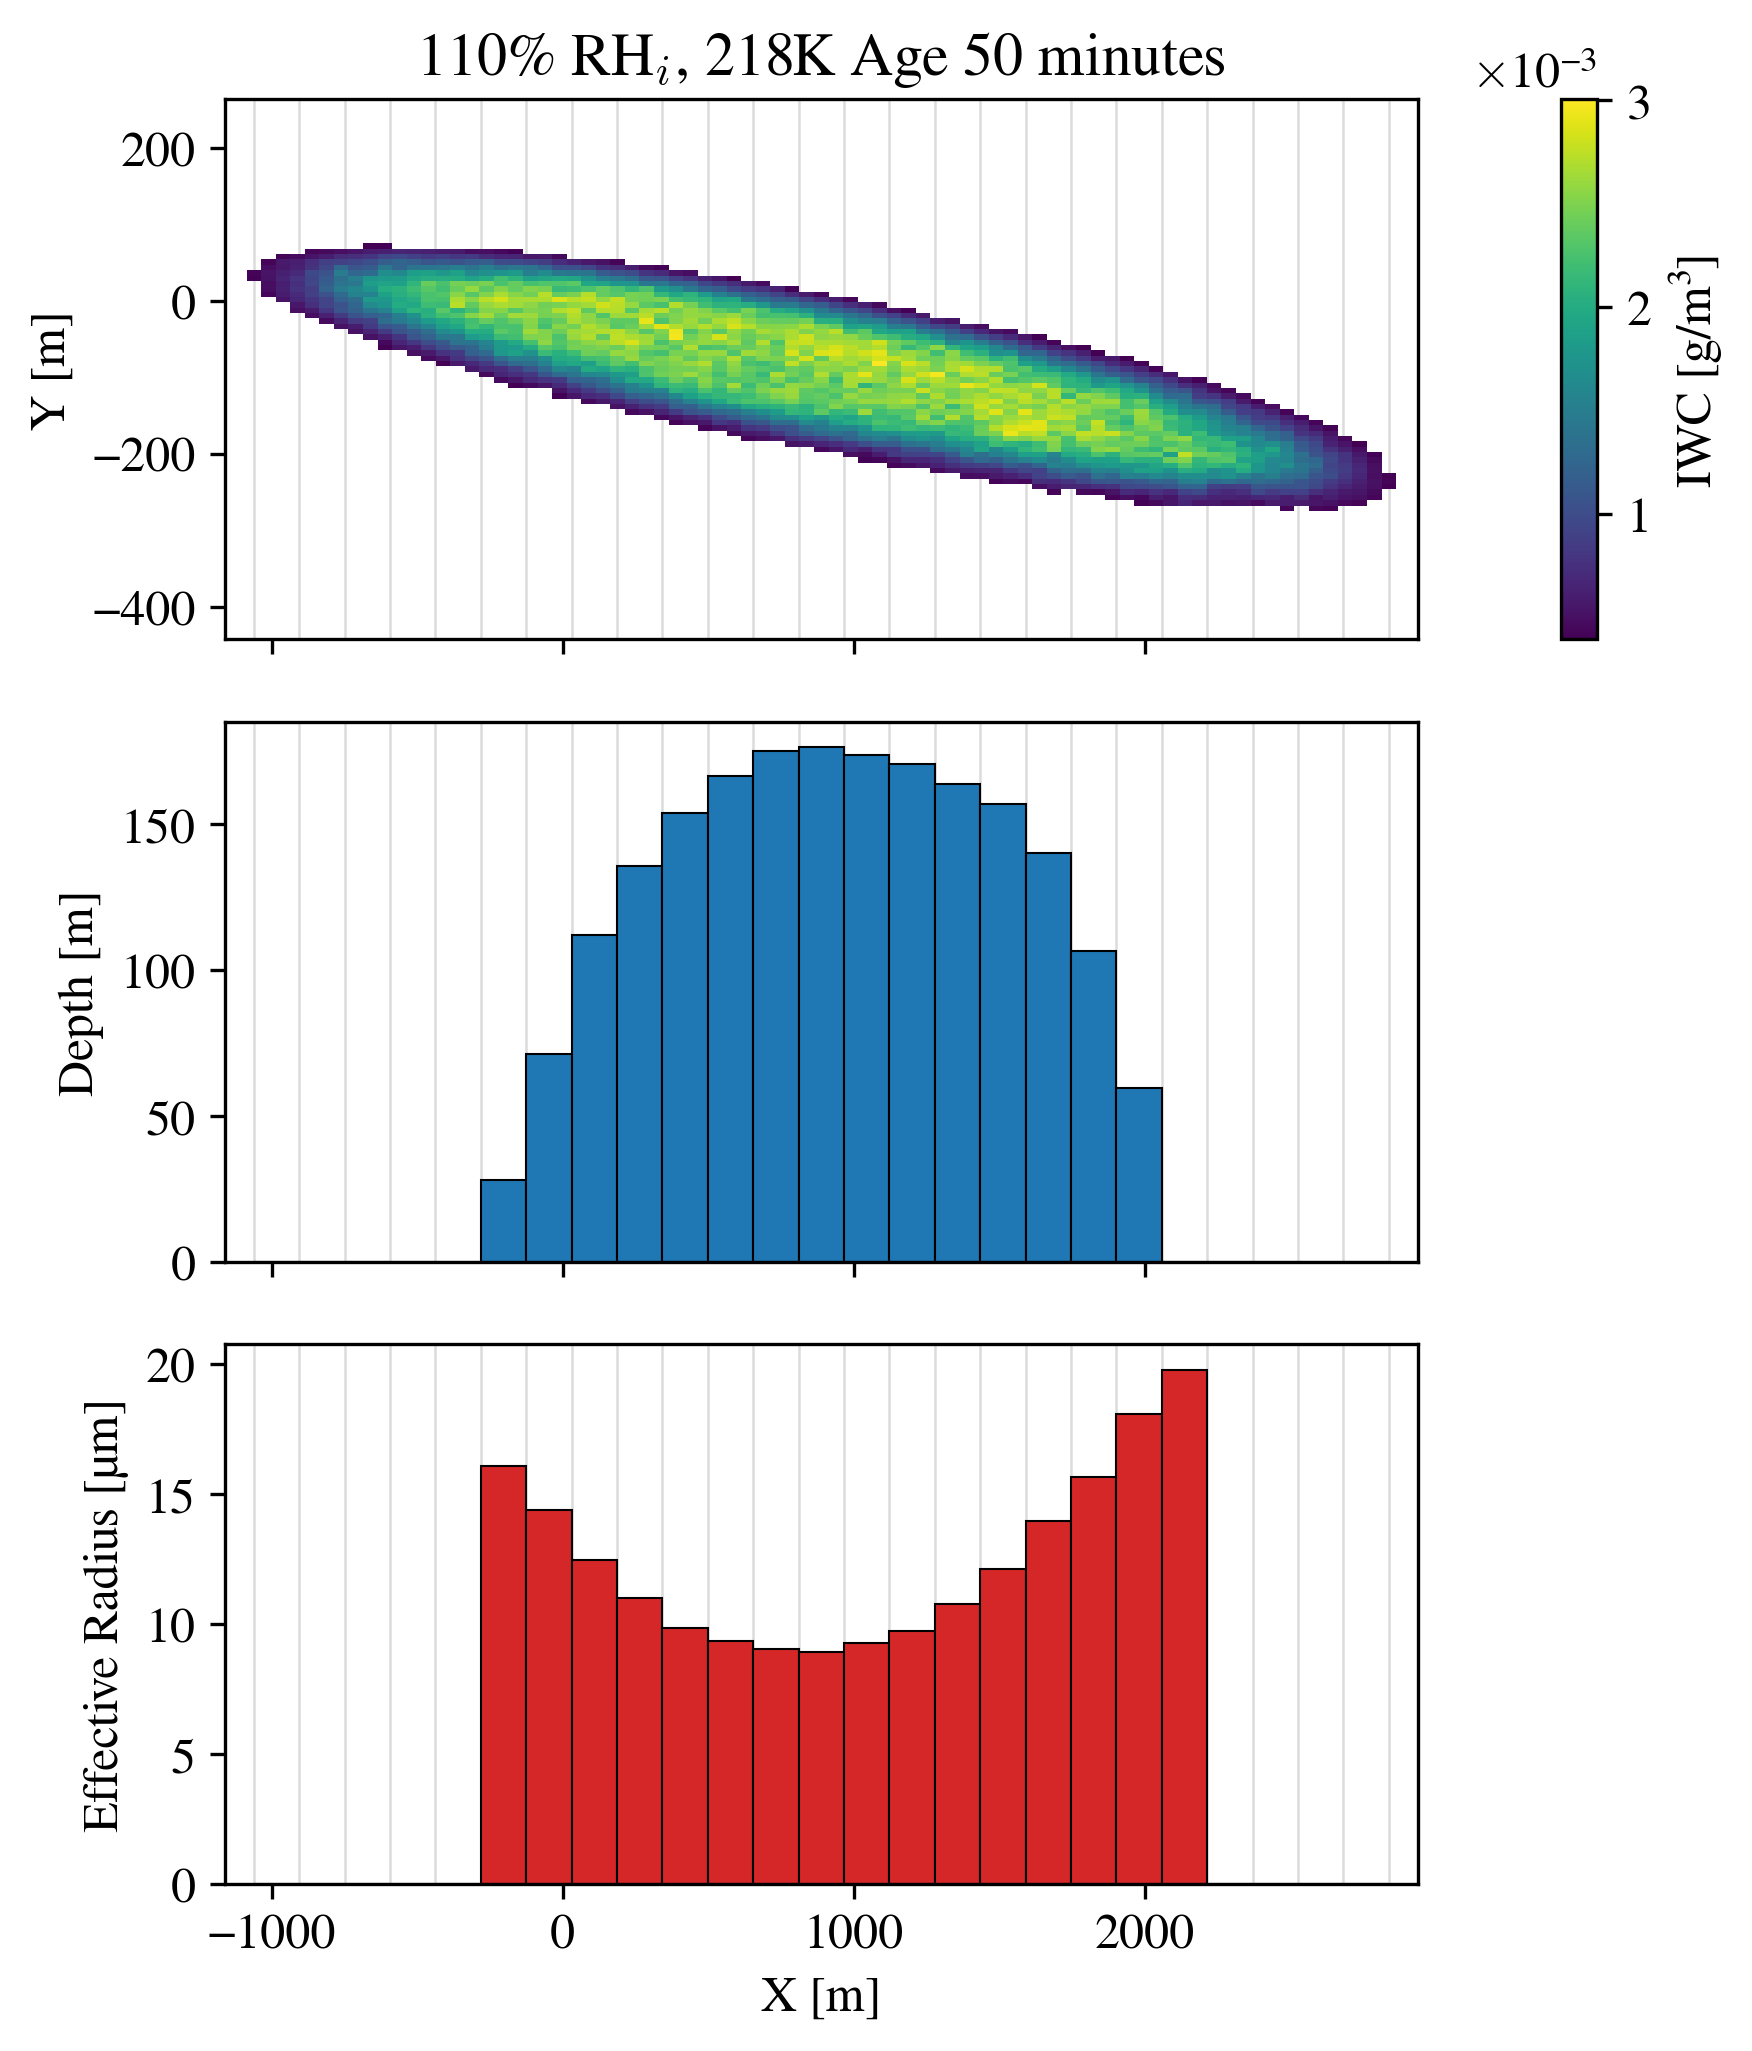

In [77]:
frame_idx = 5
ds_frame = APCEMM_ds_masked[frame_idx]

x_vals = ds_frame["x"].values
y_vals = ds_frame["y"].values
iwc_plot = ds_frame["IWC"].values * 1e3  # g/m^3

num_to_display = total_num_slices_averaged
data_radii = APCEMM_radii_slice_avg[frame_idx] * 1e-6
data_depth = APCEMM_depth_slice_avg[frame_idx]

valid_mask = np.isfinite(iwc_plot) & (iwc_plot != 0)
valid_rows = np.where(np.any(valid_mask, axis=1))[0]
valid_cols = np.where(np.any(valid_mask, axis=0))[0]

x_min_valid = x_vals[valid_cols].min()
x_max_valid = x_vals[valid_cols].max()
y_min_valid = y_vals[valid_rows].min()
y_max_valid = y_vals[valid_rows].max()

x_vals_slices = np.linspace(x_min_valid, x_max_valid, num_to_display)
x_edges = np.linspace(x_min_valid, x_max_valid, num_to_display + 1)

fig, axes = plt.subplots(
    3, 2, figsize=(6, 7), dpi=300,
    gridspec_kw={"width_ratios": [100, 3]},
    sharex="col"
)
axes[0, 0].set_title(f"110% RH$_i$, 218K Age {frame_idx*10} minutes")

axes[1, 1].remove()
axes[2, 1].remove()

im = axes[0, 0].pcolormesh(x_vals, y_vals, iwc_plot, shading="auto", cmap="viridis")
cbar = fig.colorbar(im, cax=axes[0, 1], label="IWC [g/m³]")
cbar.formatter = ticker.ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()

axes[0, 0].set_ylabel("Y [m]")
axes[0, 0].set_xlim(x_min_valid - 100, x_max_valid + 100)

valid_d = np.isfinite(data_depth)
axes[1, 0].hist(x_vals_slices[valid_d], bins=x_edges, weights=data_depth[valid_d], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[1, 0].set_ylabel("Depth [m]")

valid_r = np.isfinite(data_radii)
axes[2, 0].hist(x_vals_slices[valid_r], bins=x_edges, weights=data_radii[valid_r] * 1e6, color="tab:red", edgecolor="black", linewidth=0.5)
axes[2, 0].set_ylabel("Effective Radius [µm]")
axes[2, 0].set_xlabel("X [m]")

# Add vertical bin-edge lines to all plots
for ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
    for x_edge in x_edges:
        ax.axvline(x_edge, color="lightgray", linewidth=0.6, alpha=0.8, zorder=0)

plt.tight_layout()
plt.show()

## Make animation with inputs and outputs

In [4]:
# Create figure: 2 rows x 2 columns, right column for colorbar
fig, axes = plt.subplots(
    2, 2, figsize=(6, 6), dpi=300,
    gridspec_kw={"width_ratios": [100, 5]}
)
plt.rcParams.update({"font.size": 12})

# Keep only top-right axis for colorbar
axes[1, 1].remove()

fps_contrail = 2  # Frames per second for the contrail evolution video

# --- Compute global IWC range (g/m^3) across all timesteps for fixed log color scale ---
iwc_vmin = np.inf
iwc_vmax = -np.inf

# --- Compute global x/y coordinate ranges for fixed spatial axes ---
x_min, x_max = np.inf, -np.inf
y_min, y_max = np.inf, -np.inf

for ds_masked in APCEMM_ds_masked:
    if ds_masked is None:
        continue

    iwc_vals = ds_masked["IWC"].values * 1e3  # convert to g/m^3
    valid = iwc_vals[np.isfinite(iwc_vals) & (iwc_vals > 0)]  # LogNorm needs strictly positive values
    if valid.size > 0:
        iwc_vmin = min(iwc_vmin, valid.min())
        iwc_vmax = max(iwc_vmax, valid.max())

    x_vals = ds_masked["x"].values / 1000  # convert to km
    y_vals = ds_masked["y"].values
    if x_vals.size > 0 and y_vals.size > 0:
        x_min = min(x_min, np.nanmin(x_vals))
        x_max = max(x_max, np.nanmax(x_vals))
        y_min = min(y_min, np.nanmin(y_vals))
        y_max = max(y_max, np.nanmax(y_vals))

if not np.isfinite(iwc_vmin) or not np.isfinite(iwc_vmax):
    raise ValueError("No positive finite IWC values found for log-scaled colorbar.")

iwc_norm = LogNorm(vmin=iwc_vmin, vmax=iwc_vmax)

# Fixed colorbar (invariant across frames)
sm = ScalarMappable(norm=iwc_norm, cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, cax=axes[0, 1], label="IWC (g/m³)")

def update_contrail_frame(frame_idx):
    # Clear plotting axes
    axes[0, 0].clear()
    axes[1, 0].clear()

    time_hours = timesteps_hours[frame_idx]
    num_slices_curr = num_slices_array[frame_idx]

    # --- IWC panel ---
    ds_frame = APCEMM_ds_masked[frame_idx]
    if num_slices_curr != 0 and ds_frame is not None:
        iwc_plot = ds_frame["IWC"].values * 1e3
        iwc_plot = np.where(iwc_plot > 0, iwc_plot, np.nan)

        x_vals = ds_frame["x"].values / 1000  # convert to km
        y_vals = ds_frame["y"].values
        extent = [
            float(np.nanmin(x_vals)), float(np.nanmax(x_vals)),
            float(np.nanmin(y_vals)), float(np.nanmax(y_vals))
        ]

        axes[0, 0].imshow(
            iwc_plot,
            aspect="auto",
            cmap="viridis",
            norm=iwc_norm,
            extent=extent,
            origin="lower",
        )
    else:
        axes[0, 0].text(0.5, 0.5, "No slices", ha="center", va="center", transform=axes[0, 0].transAxes)

    axes[0, 0].set_xlabel("X [km]")
    axes[0, 0].set_ylabel("Y [m]")
    axes[0, 0].set_xlim(x_min, x_max)
    axes[0, 0].set_ylim(-700, 100)
    axes[0, 0].set_title(f"Contrail Age = {time_hours:.2f} hours")

    # --- RF panel ---
    rf_dir_frame = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_{frame_idx}"
    csv_files_frame = sorted(glob.glob(os.path.join(rf_dir_frame, "*.csv")))

    if len(csv_files_frame) > 0:
        df_list_frame = [pd.read_csv(f) for f in csv_files_frame]

        lw_0h_frame = None
        lw_12h_frame = None
        sw_12h_frame = None

        for i, f in enumerate(csv_files_frame):
            if "LW" in f and "0h" in f:
                lw_0h_frame = df_list_frame[i]
            if "LW" in f and "12h" in f:
                lw_12h_frame = df_list_frame[i]
            if "SW" in f and "12h" in f:
                sw_12h_frame = df_list_frame[i]

        if lw_0h_frame is not None:
            axes[1, 0].plot(
                range(len(lw_0h_frame)),
                lw_0h_frame["LW_Radiative_Forcing_W_m2"],
                marker="o", linestyle="-", label="LW only", color="blue"
            )
        if lw_12h_frame is not None and sw_12h_frame is not None:
            total_rf = lw_12h_frame["LW_Radiative_Forcing_W_m2"] + sw_12h_frame["SW_Radiative_Forcing_W_m2"]
            axes[1, 0].plot(
                range(len(lw_12h_frame)),
                total_rf,
                marker="o", linestyle="-", label="LW + Max SW", color="red"
            )
    else:
        axes[1, 0].text(
            0.5, 0.5, f"No RF data at timestep {frame_idx}",
            ha="center", va="center", transform=axes[1, 0].transAxes
        )

    axes[1, 0].set_ylabel("Radiative Forcing (W/m²)")
    axes[1, 0].set_ylim(-1.5, 12)
    axes[1, 0].set_xlabel("")
    axes[1, 0].set_xticks([])
    axes[1, 0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    handles, labels = axes[1, 0].get_legend_handles_labels()
    if handles:
        axes[1, 0].legend()

    plt.tight_layout()
    return axes

anim_contrail = FuncAnimation(
    fig, update_contrail_frame, frames=len(timesteps), interval=1000 / fps_contrail, blit=False
)

# Save animation
output_path_contrail = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/contrail_evolution_RF_only_{test_id}.mp4"
writer_contrail = FFMpegWriter(fps=fps_contrail, bitrate=2000)
anim_contrail.save(output_path_contrail, writer=writer_contrail)

print(f"Contrail evolution video saved to: {output_path_contrail}")
plt.close()

Contrail evolution video saved to: /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/contrail_evolution_RF_only_110T218L25.mp4


In [ ]:
# EF data (loaded once)
path_0h = "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/110T225L25/EF/110T225L25_EF_ghm_0h_LRT.csv"
path_12h = "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/110T225L25/EF/110T225L25_EF_ghm_12h_LRT.csv"

df_0h = pd.read_csv(path_0h)
df_12h = pd.read_csv(path_12h)

# 2 rows x 1 column (EF only)
fig, axes = plt.subplots(2, 1, figsize=(6, 6), dpi=300, sharex=True)
plt.rcParams.update({"font.size": 12})

fps_contrail = 2

# Fixed axis limits for stable animation
ef_xmax = float(max(df_0h["Contrail_Age_hours"].max(), df_12h["Contrail_Age_hours"].max()))
ef_ymin = float(min(df_0h["EF_J_m"].min(), df_12h["EF_J_m"].min()))
ef_ymax = float(max(df_0h["EF_J_m"].max(), df_12h["EF_J_m"].max()))

# Keep limits stable and symlog-friendly
ymin_0h = min(1e6, ef_ymin if ef_ymin > 0 else 1e6)
ymin_12h = min(-1e6, ef_ymin)
ymax_all = max(1e10, ef_ymax * 1.05)

def update_contrail_frame(frame_idx):
    for ax in axes:
        ax.clear()

    time_hours = timesteps_hours[frame_idx]

    # Midnight EF
    df_0h_now = df_0h[df_0h["Contrail_Age_hours"] <= time_hours]
    axes[0].plot(df_0h_now["Contrail_Age_hours"], df_0h_now["EF_J_m"], color="blue")
    axes[0].set_title("LW only")
    axes[0].set_ylabel("Energy forcing [J/m]")
    axes[0].set_yscale("symlog")
    axes[0].set_xlim(0, ef_xmax)
    axes[0].set_ylim(ymin_0h, ymax_all)

    # Noon EF
    df_12h_now = df_12h[df_12h["Contrail_Age_hours"] <= time_hours]
    axes[1].plot(df_12h_now["Contrail_Age_hours"], df_12h_now["EF_J_m"], color="red")
    axes[1].set_title("LW + Max SW")
    axes[1].set_xlabel("Contrail Age [hours]")
    axes[1].set_ylabel("Energy forcing [J/m]")
    axes[1].set_yscale("symlog")
    axes[1].set_xlim(0, ef_xmax)
    axes[1].set_ylim(ymin_12h, ymax_all)
    #Only plot every other y tick label to reduce clutter (Noon EF subplot)
    y_ticks = axes[1].get_yticks()
    axes[1].set_yticks(y_ticks[::2])  # Only show every other tick

    fig.suptitle(f"Contrail Age = {time_hours:.2f} hours")
    plt.tight_layout()
    return axes

anim_contrail = FuncAnimation(
    fig, update_contrail_frame, frames=len(timesteps), interval=1000 / fps_contrail, blit=False
)

output_path_contrail = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/contrail_evolution_EF_only_{test_id}.mp4"
writer_contrail = FFMpegWriter(fps=fps_contrail, bitrate=2000)
anim_contrail.save(output_path_contrail, writer=writer_contrail)

print(f"EF-only animation saved to: {output_path_contrail}")
plt.close()


In [ ]:
# Create figure for animation with 6 rows
fig, axes = plt.subplots(6, 2, figsize=(12, 18), gridspec_kw={'width_ratios': [100, 5]}, dpi=300)
axes[0,1].remove()
axes[1,1].remove()
axes[2,1].remove()
axes[4,1].remove()
axes[5,1].remove()

cbar = None
fps_contrail = 2  # Frames per second for the contrail evolution video

def update_contrail_frame(frame_idx):
    global cbar

    for ax in axes.flat:
        if ax.figure is not None and ax is not axes[3,1]:
            ax.clear()
    
    time_hours = timesteps_hours[frame_idx]
    num_slices_curr = num_slices_array[frame_idx]
    
    if num_slices_curr == 0:
        return axes
    
    # Calculate number of slices to display
    if num_slices_curr > total_num_slices_averaged:
        num_to_display = total_num_slices_averaged
        data_radii = APCEMM_radii_slice_avg[frame_idx, :]
        data_iwc = APCEMM_IWC_slice_avg[frame_idx, :]
        data_depth = APCEMM_depth_slice_avg[frame_idx, :]
    else:
        num_to_display = num_slices_curr
        data_radii = APCEMM_radii[frame_idx, :num_slices_curr]
        data_iwc = APCEMM_IWC_avg[frame_idx, :num_slices_curr]
        data_depth = APCEMM_depth[frame_idx, :num_slices_curr]
    
    # Load RF data for this timestep
    rf_dir_frame = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_{frame_idx}"
    csv_files_frame = sorted(glob.glob(os.path.join(rf_dir_frame, "*.csv")))
    
    if len(csv_files_frame) == 0:
        axes[0,0].text(0.5, 0.5, f'No data at timestep {frame_idx}', ha='center', va='center')
        axes[1,0].text(0.5, 0.5, f'No data at timestep {frame_idx}', ha='center', va='center')
        return axes
    
    df_list_frame = [pd.read_csv(f) for f in csv_files_frame]
    
    # Find relevant dataframes
    lw_0h_frame = None
    lw_12h_frame = None
    sw_12h_frame = None
    
    for i, f in enumerate(csv_files_frame):
        if "LW" in f and "0h" in f:
            lw_0h_frame = df_list_frame[i]
        if "LW" in f and "12h" in f:
            lw_12h_frame = df_list_frame[i]
        if "SW" in f and "12h" in f:
            sw_12h_frame = df_list_frame[i]

    # Top subplot: Mean effective radius
    axes[0,0].bar(range(num_to_display), data_radii[:num_to_display] * 1e6)
    axes[0,0].set_ylabel('Effective Radius (μm)')
    axes[0,0].set_title(f'Mean Effective Radius per Slice, Time = {time_hours:.2f} hours')
    axes[0,0].grid(axis='y', alpha=0.3)
    axes[0,0].set_ylim(0, 40)
    
    # Second subplot: Average IWC
    axes[1,0].bar(range(num_to_display), data_iwc[:num_to_display] * 1e3)
    axes[1,0].set_ylabel('Average IWC (g/m³)')
    axes[1,0].set_title(f'95% Average IWC per Slice, Time = {time_hours:.2f} hours')
    axes[1,0].grid(axis='y', alpha=0.3)
    axes[1,0].set_ylim(0, 0.0025)
    
    # Third subplot: Depth
    axes[2,0].bar(range(num_to_display), data_depth[:num_to_display])
    axes[2,0].set_ylabel('Depth (m)')
    axes[2,0].set_title(f'Contrail Depth per Slice, Time = {time_hours:.2f} hours')
    axes[2,0].grid(axis='y', alpha=0.3)
    axes[2,0].set_ylim(0, 600)
    
    # Bottom subplot: IWC heatmap
    im = axes[3,0].imshow(APCEMM_ds_masked[frame_idx]['IWC'].values * 1e3, aspect='auto', cmap='viridis')
    axes[3,0].set_xlabel('X [m]')
    axes[3,0].set_ylabel('Y [m]')
    axes[3,0].set_title(f'IWC, Time = {time_hours:.2f} hours')

    if cbar is None:
        cbar = fig.colorbar(im, cax=axes[3,1], label='IWC (g/m³)')
    else:
        cbar.update_normal(im)
        cbar.set_label('IWC (g/m³)')
    
    # Row 4: RF at 0h
    if lw_0h_frame is not None:
        axes[4,0].plot(range(len(lw_0h_frame)), lw_0h_frame["LW_Radiative_Forcing_W_m2"], marker="o", linestyle="-")
        axes[4,0].set_title("0 h (LW only)")
        axes[4,0].set_xlabel("Row Number")
        axes[4,0].set_ylabel("LW Radiative Forcing (W/m²)")
        axes[4,0].grid(alpha=0.3)
        axes[4,0].set_ylim(0,8)
    
    # Row 5: RF at 12h
    if lw_12h_frame is not None and sw_12h_frame is not None:
        total_rf = lw_12h_frame["LW_Radiative_Forcing_W_m2"] + sw_12h_frame["SW_Radiative_Forcing_W_m2"]
        axes[5,0].plot(range(len(lw_12h_frame)), total_rf, marker="o", linestyle="-")
        axes[5,0].set_title("12 h (LW + SW)")
        axes[5,0].set_xlabel("Row Number")
        axes[5,0].set_ylabel("LW + SW Radiative Forcing (W/m²)")
        axes[5,0].grid(alpha=0.3)
        axes[5,0].set_ylim(-2,0.5)
    
    plt.tight_layout()
    return axes

anim_contrail = FuncAnimation(fig, update_contrail_frame, frames=len(timesteps), interval=1000/fps_contrail, blit=False)

# Save animation
output_path_contrail = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/contrail_evolution_{test_id}.mp4"
writer_contrail = FFMpegWriter(fps=fps_contrail, bitrate=2000)
anim_contrail.save(output_path_contrail, writer=writer_contrail)

print(f"Contrail evolution video saved to: {output_path_contrail}")
plt.close()


# Plot the RF vs time

## Single sliced RF plot

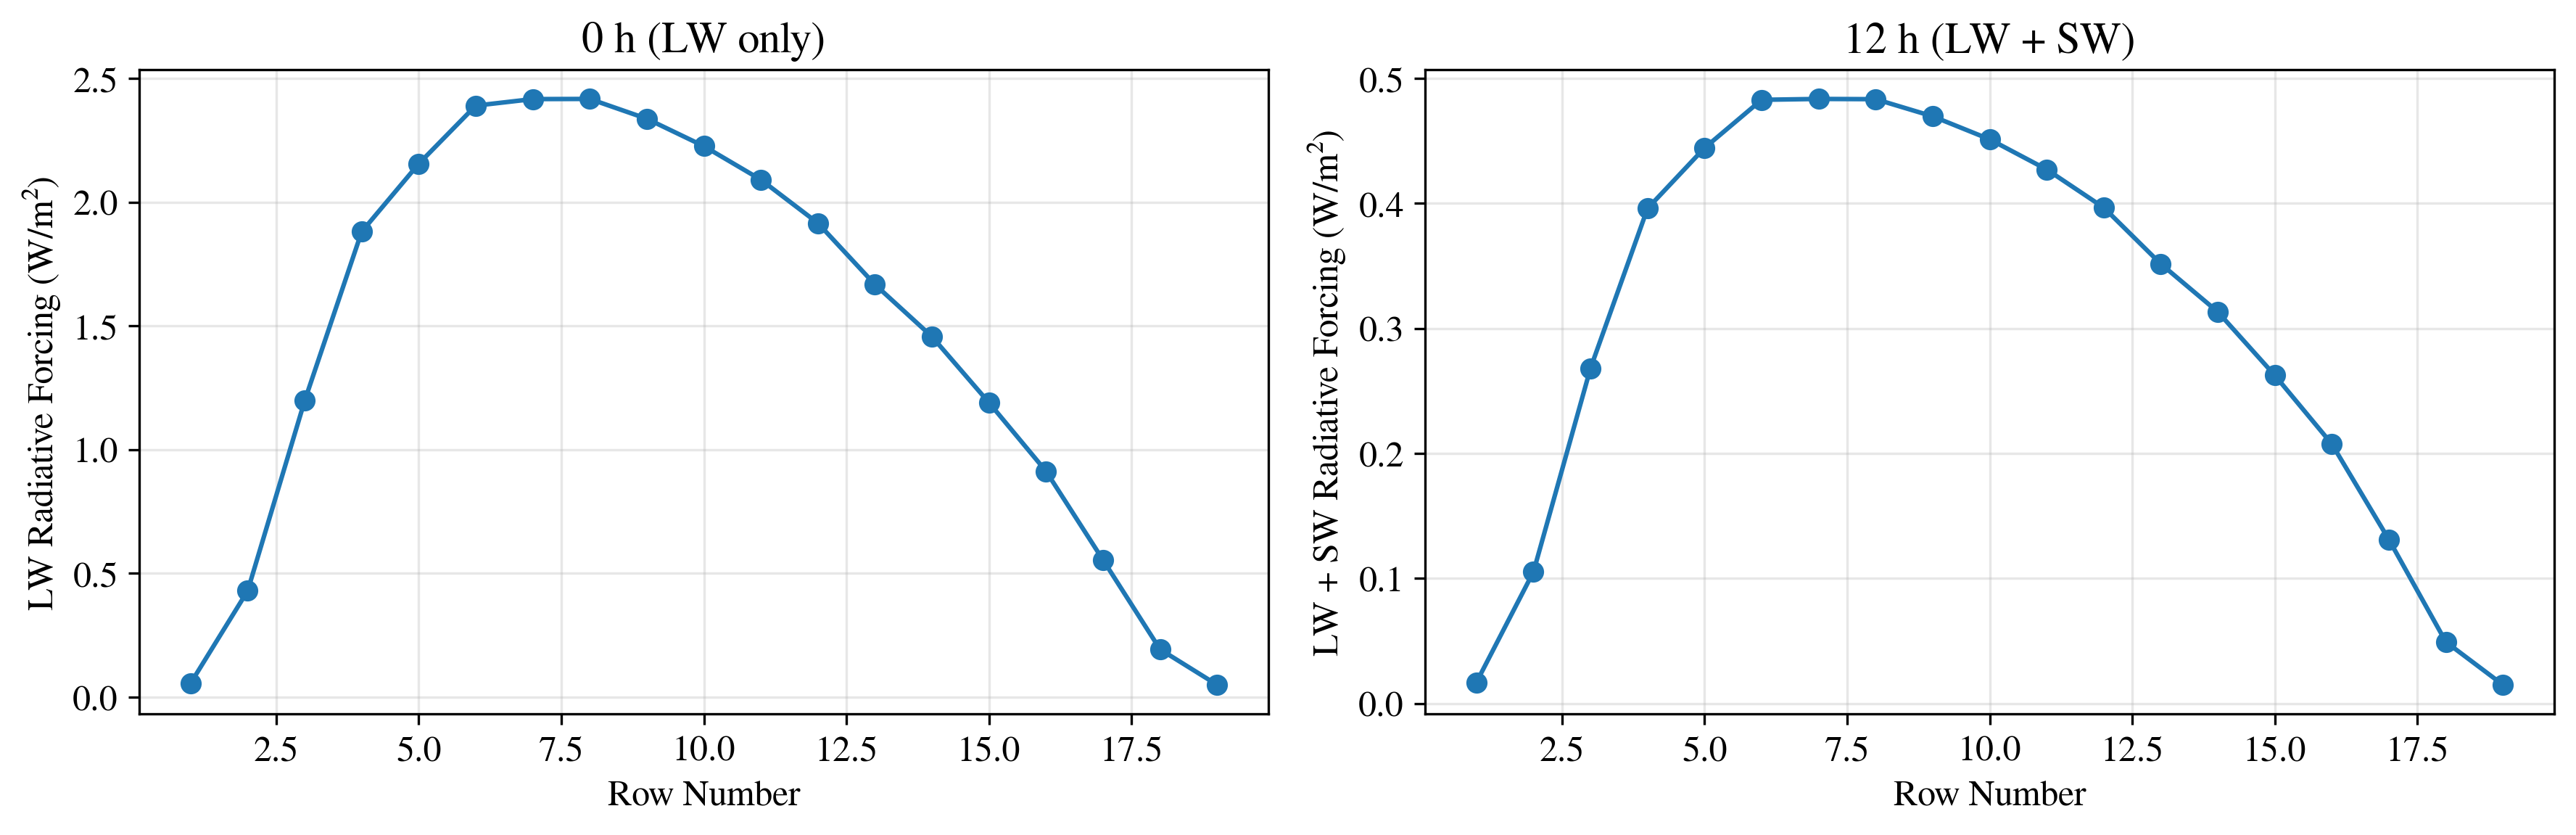

In [79]:
hour = 10
timestep = hour * 6
rf_dir = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/RF_EF_results/slicing_results/110T218L25/RF/outputs/timestep_{timestep}"
csv_files = sorted(glob.glob(os.path.join(rf_dir, "*.csv")))

df_list = [pd.read_csv(f) for f in csv_files]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

# Find 0h LW file and 12h LW + SW files
lw_0h_df = None
lw_12h_df = None
sw_12h_df = None

for i, f in enumerate(csv_files):
    if '0h' in f and 'LW' in f:
        lw_0h_df = df_list[i]
    elif '12h' in f and 'LW' in f:
        lw_12h_df = df_list[i]
    elif '12h' in f and 'SW' in f:
        sw_12h_df = df_list[i]

# Plot 0h (LW only)
if lw_0h_df is not None:
    axes[0].plot(range(len(lw_0h_df)), lw_0h_df["LW_Radiative_Forcing_W_m2"], marker="o", linestyle="-")
    axes[0].set_title("0 h (LW only)")
    axes[0].set_xlabel("Row Number")
    axes[0].set_ylabel("LW Radiative Forcing (W/m²)")
    axes[0].grid(alpha=0.3)

# Plot 12h (LW + SW)
if lw_12h_df is not None and sw_12h_df is not None:
    total_rf = lw_12h_df["LW_Radiative_Forcing_W_m2"] + sw_12h_df["SW_Radiative_Forcing_W_m2"]
    axes[1].plot(range(len(lw_12h_df)), total_rf, marker="o", linestyle="-")
    axes[1].set_title("12 h (LW + SW)")
    axes[1].set_xlabel("Row Number")
    axes[1].set_ylabel("LW + SW Radiative Forcing (W/m²)")
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Plot average RF vs time: slicing vs no slicing

# CoCiP Slicing Post-Processing

In [15]:
habits = ["solid-column"] #["rough-aggregate", "ghm", "solid-column"]
test_ids = ["110T218L25"] #"110T205L25", "110T218L25", "110T225L25", "130T205L25", "130T218L25", "130T225L25"]

for test_id in test_ids:
    cocip_data = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass.nc")
    rf_dir_base = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/RF_EF_results/slicing_results/{test_id}/RF/outputs"
    timesteps = np.arange(int(len(cocip_data['age_hours'].values) / 10)) # Assuming each timestep corresponds to 10 minutes, and 'age_hours' is in hours
    time_hours = timesteps*10 / 60  # Convert each timestep from 10 minutes to hours

    for habit in habits:
        rf_0h_slice_avg = []
        rf_12h_slice_avg = []
        rf_12h_slice_avg_sw_only = []
        rf_12h_slice_avg_lw_only = []
        
        for time_idx in timesteps:
            rf_dir_time = f"{rf_dir_base}/timestep_{time_idx}"
            csv_files_time = sorted(glob.glob(os.path.join(rf_dir_time, f"*{habit}*.csv")))
            print(f"Processing {len(csv_files_time)} RF CSV files for {test_id} - {habit} at time index {time_idx} (age {time_hours[time_idx]:.2f} hours)")

            df_list_time = [pd.read_csv(f) for f in csv_files_time]
    
            lw_0h_time = None
            lw_12h_time = None
            sw_12h_time = None
    
            for i, f in enumerate(csv_files_time):
                if "LW" in f and "0h" in f:
                    lw_0h_time = df_list_time[i]
                if "LW" in f and "12h" in f:
                    lw_12h_time = df_list_time[i]
                if "SW" in f and "12h" in f:
                    sw_12h_time = df_list_time[i]
    
            # if the value is 0 dont include it in the average (will later be replaced with nan, but for now just skip it in the average)
            if lw_0h_time is not None:
                lw_0h_time["LW_Radiative_Forcing_W_m2"] = lw_0h_time["LW_Radiative_Forcing_W_m2"].replace(0, np.nan)
                rf_0h_slice_avg.append(lw_0h_time["LW_Radiative_Forcing_W_m2"].mean())
    
            if lw_12h_time is not None and sw_12h_time is not None:
                lw_12h_time["LW_Radiative_Forcing_W_m2"] = lw_12h_time["LW_Radiative_Forcing_W_m2"].replace(0, np.nan)
                sw_12h_time["SW_Radiative_Forcing_W_m2"] = sw_12h_time["SW_Radiative_Forcing_W_m2"].replace(0, np.nan)
                total_rf_12h = lw_12h_time["LW_Radiative_Forcing_W_m2"] + sw_12h_time["SW_Radiative_Forcing_W_m2"]
                rf_12h_slice_avg.append(total_rf_12h.mean())
                rf_12h_slice_avg_sw_only.append(sw_12h_time["SW_Radiative_Forcing_W_m2"].mean())
                rf_12h_slice_avg_lw_only.append(lw_12h_time["LW_Radiative_Forcing_W_m2"].mean())

        print(f"Lengths of dataframe variables for {test_id} - {habit}:")
        print(f"  - time_hours: {len(time_hours)}")
        print(f"  - rf_0h_slice_avg: {len(rf_0h_slice_avg)}")
        print(f"  - rf_12h_slice_avg: {len(rf_12h_slice_avg)}")
        print(f"  - rf_12h_slice_avg_sw_only: {len(rf_12h_slice_avg_sw_only)}")
        print(f"  - rf_12h_slice_avg_lw_only: {len(rf_12h_slice_avg_lw_only)}")

        # Save the average RF values over time to three separate CSV files
        # Create dataframe for LW 0h
        rf_0h_df = pd.DataFrame({
            "Contrail_Age_hours": time_hours,
            "LW_Radiative_Forcing_W_m2": rf_0h_slice_avg
        })
        rf_0h_df.to_csv(
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/RF_EF_results/slicing_results/{test_id}/RF/outputs/LW_RF_cocip_{habit}_0h_IWC_{test_id}.csv",
            index=False
        )
    
        # Create dataframe for LW 12h
        rf_12h_lw_df = pd.DataFrame({
            "Contrail_Age_hours": time_hours,
            "LW_Radiative_Forcing_W_m2": rf_12h_slice_avg_lw_only
        })
        rf_12h_lw_df.to_csv(
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/RF_EF_results/slicing_results/{test_id}/RF/outputs/LW_RF_cocip_{habit}_12h_IWC_{test_id}.csv",
            index=False
        )
    
        # Create dataframe for SW 12h
        rf_12h_sw_df = pd.DataFrame({
            "Contrail_Age_hours": time_hours,
            "SW_Radiative_Forcing_W_m2": rf_12h_slice_avg_sw_only
        })
        rf_12h_sw_df.to_csv(
            f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/RF_EF_results/slicing_results/{test_id}/RF/outputs/SW_RF_cocip_{habit}_12h_IWC_{test_id}.csv",
            index=False
        )

Processing 1 RF CSV files for 110T218L25 - solid-column at time index 0 (age 0.00 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 1 (age 0.17 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 2 (age 0.33 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 3 (age 0.50 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 4 (age 0.67 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 5 (age 0.83 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 6 (age 1.00 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 7 (age 1.17 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 8 (age 1.33 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 9 (age 1.50 hours)
Processing 1 RF CSV files for 110T218L25 - solid-column at time index 10 (age 1.67 hours)
Processing 1 RF CSV 

ValueError: All arrays must be of the same length